In [ ]:
from environment import Environment
from Q_learning_algorithm import q_learning_with_eval
import numpy as np
import pandas as pd

alpha_list = [0.5, 0.3, 0.1]
gamma_list = [0.8, 0.95, 0.99]
seeds = [1, 2, 3]
decay = 0.9999
epsilon = 1.0
epsilon_min = 0.05
episodes = 3
eval_every = 5000

summary_rows = []
long_rows = []

for a in alpha_list:
    for g in gamma_list:
        for seed in seeds:
            print(f"alpha={a}, gamma={g}, seed={seed}")

            env = Environment(seed=seed)
            q_table, eval_steps, eval_rewards, eval_waste, eval_fill_rate = q_learning_with_eval(
                epsilon=epsilon, gamma=g, alpha=a, decay=decay, epsilon_min=epsilon_min,
                episodes=episodes, enviroment=env, eval_every=eval_every, eval_seed=seed + 1000
            )

            # final stats: mean of last 5 eval points
            summary_rows.append({
                'alpha': a,
                'gamma': g,
                'seed': seed,
                'profit': np.mean(eval_rewards[-5:]),
                'waste_pct': np.mean(eval_waste[-5:]) * 100,
                'fill_rate_pct': np.mean(eval_fill_rate[-5:]) * 100,
            })

            # full eval curve, long format
            for step, r, w, f in zip(eval_steps, eval_rewards, eval_waste, eval_fill_rate):
                long_rows.append({
                    'alpha': a,
                    'gamma': g,
                    'seed': seed,
                    'step': step,
                    'profit': r,
                    'waste_pct': w * 100,
                    'fill_rate_pct': f * 100,
                })

            # save incrementally in case of crash
            pd.DataFrame(summary_rows).to_csv('hyperparameter_tuning_summary.csv', index=False)
            pd.DataFrame(long_rows).to_csv('hyperparameter_tuning_long.csv', index=False)

print("Finished")

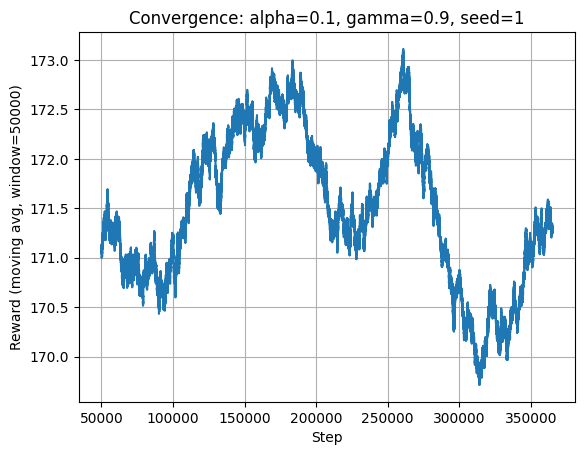

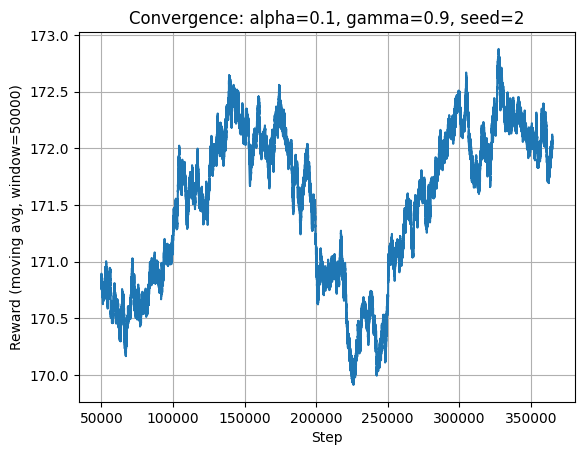

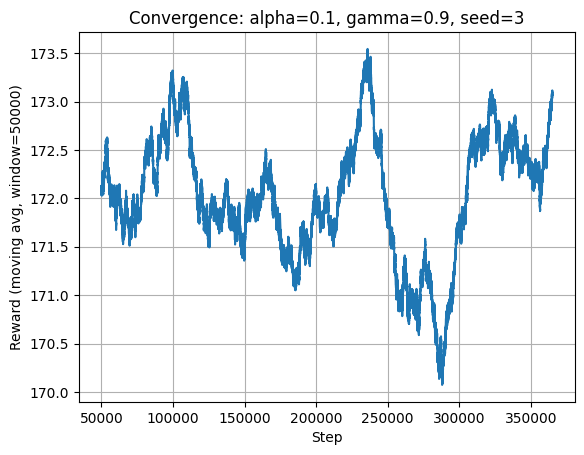

In [ ]:
rewards_df = pd.read_csv('hyperparameter_tuning_long.csv')

window = 50000

for (a, g, s), group in rewards_df.groupby(['alpha', 'gamma', 'seed']):
    ma = group['reward'].rolling(window).mean()
    plt.figure()
    plt.plot(group['episode'], ma)        # of group['episode'] als je die kolomnaam houdt
    plt.xlabel("Step")
    plt.ylabel(f"Reward (moving avg, window={window})")
    plt.title(f"Convergence: alpha={a}, gamma={g}, seed={s}")
    plt.grid(True)
    plt.show()
